Sales Summary:
   product  total_qty  revenue
0  Laptop          8   6460.0
1   Phone         25  12400.0
2  Tablet         12   3640.0


<Figure size 800x500 with 0 Axes>

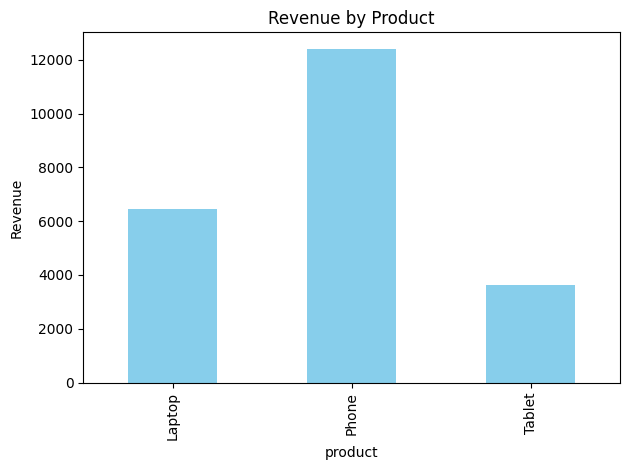

<Figure size 800x500 with 0 Axes>

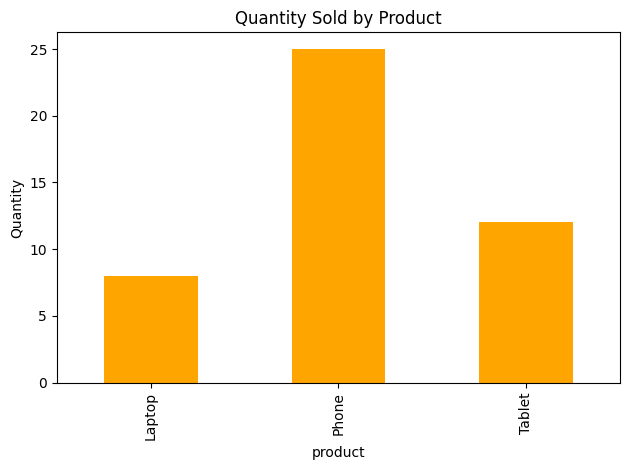

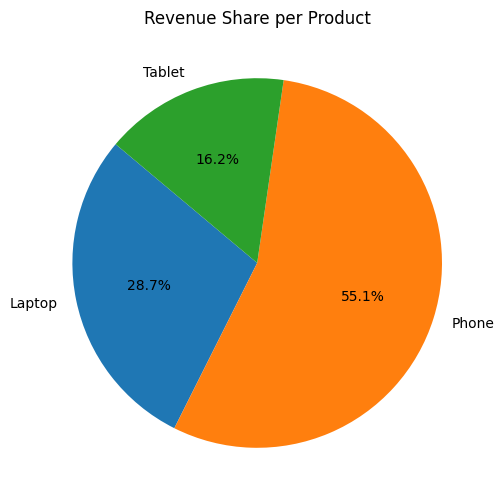

<Figure size 800x500 with 0 Axes>

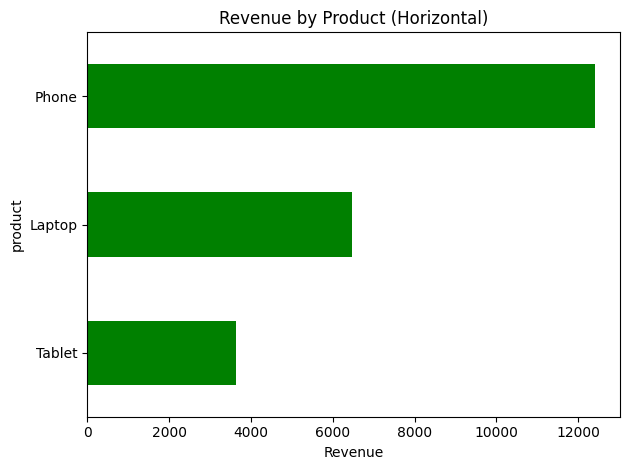

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales.db")
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

sample_data = [
    ('Laptop', 5, 800.0),
    ('Tablet', 8, 300.0),
    ('Phone', 15, 500.0),
    ('Laptop', 3, 820.0),
    ('Tablet', 4, 310.0),
    ('Phone', 10, 490.0)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)
print("Sales Summary:\n", df)

plt.figure(figsize=(8,5))
df.plot(kind='bar', x='product', y='revenue', color='skyblue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
df.plot(kind='bar', x='product', y='total_qty', color='orange', legend=False)
plt.title("Quantity Sold by Product")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.pie(df['revenue'], labels=df['product'], autopct='%1.1f%%', startangle=140)
plt.title("Revenue Share per Product")
plt.show()

plt.figure(figsize=(8,5))
df.sort_values(by='revenue').plot(kind='barh', x='product', y='revenue', color='green', legend=False)
plt.title("Revenue by Product (Horizontal)")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()